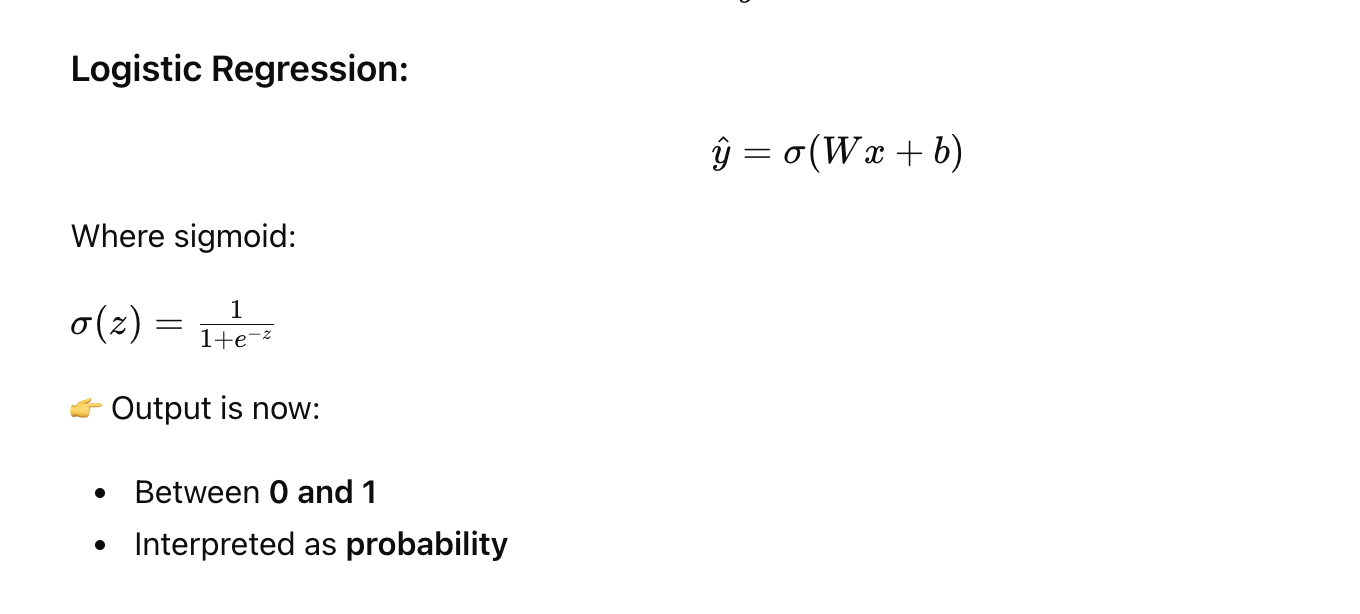

### Problem Setup: Binary Classification

In this task, we are solving a binary classification problem where the output can be either:
- 0 (negative class)
- 1 (positive class)

Unlike linear regression (which predicts continuous values), here we predict probabilities and classify data points into two categories.

In [6]:
# Library & Dataset

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Create dataset
X = np.random.randn(100, 2)

# Decision boundary: x1 + x2 > 0 → class 1
y = (X[:, 0] + X[:, 1] > 0).astype(int).reshape(-1, 1)

### Dataset Explanation

We generate synthetic data with 2 features.

The decision boundary is:
x₁ + x₂ > 0

- If true → class 1
- If false → class 0

This creates a line separating the two classes.

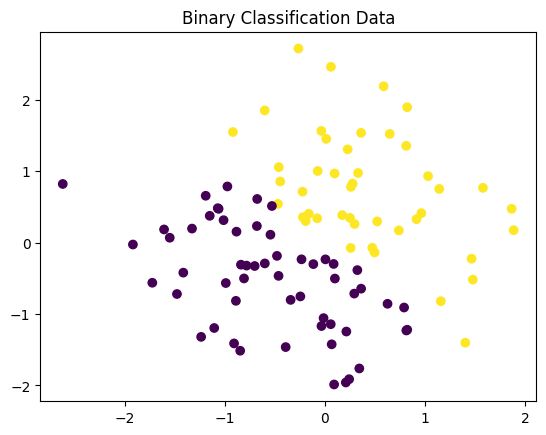

In [7]:
# Visualize

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Binary Classification Data")
plt.show()

In [9]:
# Initialize Parameters

W = np.random.randn(2, 1)
b = np.random.randn(1)

### Sigmoid Function

The sigmoid function converts any real number into a value between 0 and 1.

This allows us to interpret the output as a probability.

σ(z)=1/(1+e^−z)

In [10]:
# Sigmoid Function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Forward Pass (Prediction)

The model computes:

z = XW + b

Then applies sigmoid:

ŷ = sigmoid(z)

This gives probability of belonging to class 1.

In [11]:
# Forward Pass

def predict_proba(X, W, b):
    return sigmoid(X @ W + b)

### Loss Function: Binary Cross Entropy

We use Binary Cross Entropy instead of MSE.

Why?
- MSE is not suitable for probabilities
- BCE penalizes wrong predictions more strongly

In [12]:
# Loss Function (Binary Cross Entropy)

def compute_loss(y, y_pred):
    m = len(y)
    return -np.mean(
        y * np.log(y_pred + 1e-8) + 
        (1 - y) * np.log(1 - y_pred + 1e-8) # 1e-8 → avoids log(0) error
    )

### Gradients

Gradients tell us how to update model parameters to reduce loss.

For logistic regression:

- dW = (1/m) Xᵀ (y_pred - y)
- db = (1/m) sum(y_pred - y)

These guide the optimization process.

In [13]:
# Gradients

def compute_gradients(X, y, y_pred):
    m = len(X)
    
    dW = (1/m) * X.T @ (y_pred - y)
    db = (1/m) * np.sum(y_pred - y)
    
    return dW, db

### Training Loop

The model learns iteratively through:

1. Forward pass → predictions
2. Compute loss → measure error
3. Compute gradients → direction to update
4. Update parameters → improve model

This process is repeated for multiple epochs until convergence.

In [14]:
# Training Loop

learning_rate = 0.1
epochs = 500

losses = []

for epoch in range(epochs):
    y_pred = predict_proba(X, W, b)
    
    loss = compute_loss(y, y_pred)
    losses.append(loss)
    
    dW, db = compute_gradients(X, y, y_pred)
    
    W -= learning_rate * dW
    b -= learning_rate * db
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 0.670697757250502
Epoch 50, Loss: 0.32319898349415505
Epoch 100, Loss: 0.2513025809011436
Epoch 150, Loss: 0.21868520687424373
Epoch 200, Loss: 0.1983998311254874
Epoch 250, Loss: 0.18392453566417782
Epoch 300, Loss: 0.17281490900007238
Epoch 350, Loss: 0.16389387857974583
Epoch 400, Loss: 0.15650267366923512
Epoch 450, Loss: 0.15023529688637627


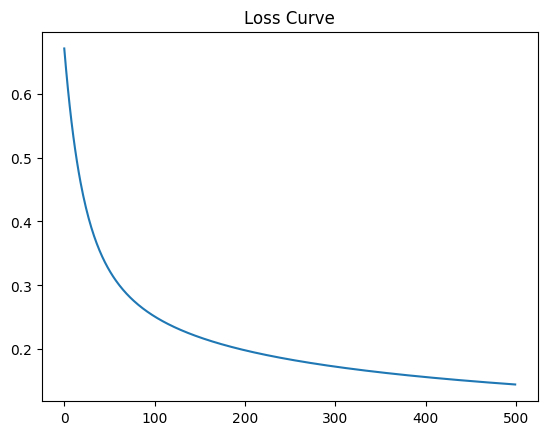

In [15]:
# Plot Loss

plt.plot(losses)
plt.title("Loss Curve")
plt.show()

### Prediction

The model outputs probabilities.

To convert to class labels:
- If probability ≥ 0.5 → class 1
- Else → class 0

In [19]:
# Prediction

def predict(X, W, b):
    probs = predict_proba(X, W, b)
    return (probs >= 0.5).astype(int)


### Model Evaluation

Accuracy measures how many predictions are correct.

Accuracy = Correct Predictions / Total Predictions

In [18]:
# Accuracy

y_pred_labels = predict(X, W, b)

accuracy = np.mean(y_pred_labels == y)
print("Accuracy:", accuracy)

Accuracy: 0.99


### Key Takeaways

- Logistic regression is used for classification tasks
- Sigmoid function converts outputs into probabilities (0 or 1)
- Binary cross-entropy is used as loss function
- Gradient descent is used to optimize parameters
- The model learns by minimizing classification error